# Anomaly Detection: Silicon Thermal Hotspots## Isolation Forest, t-SNE & UMAP on Chip Thermal Data**Project:** 007 — The AI Engineering Lab  **Objective:** Detect thermal anomalies in silicon chip data.  **Advanced Concepts:** Ensemble anomaly scoring, UMAP for visualization, ROC at extreme class imbalance.

---## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, classification_report
import umap

COLORS = {'primary': '#0D47A1', 'secondary': '#FF6F00', 'highlight': '#C62828'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Libraries loaded.')

Libraries loaded.


---## 2. Load Data

In [2]:
df = pd.read_csv('../data/silicon_thermal_hotspots.csv')
print(f'Shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts().to_string()}')
y_true = (df['label'] == 'anomaly').astype(int)
X = df.drop(columns=['label'])
feature_names = X.columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'\nAnomaly rate: {y_true.mean()*100:.1f}%')

Shape: (9300, 9)
Label distribution:
label
0    9000
1     300

Anomaly rate: 0.0%


---## 3. EDA

/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


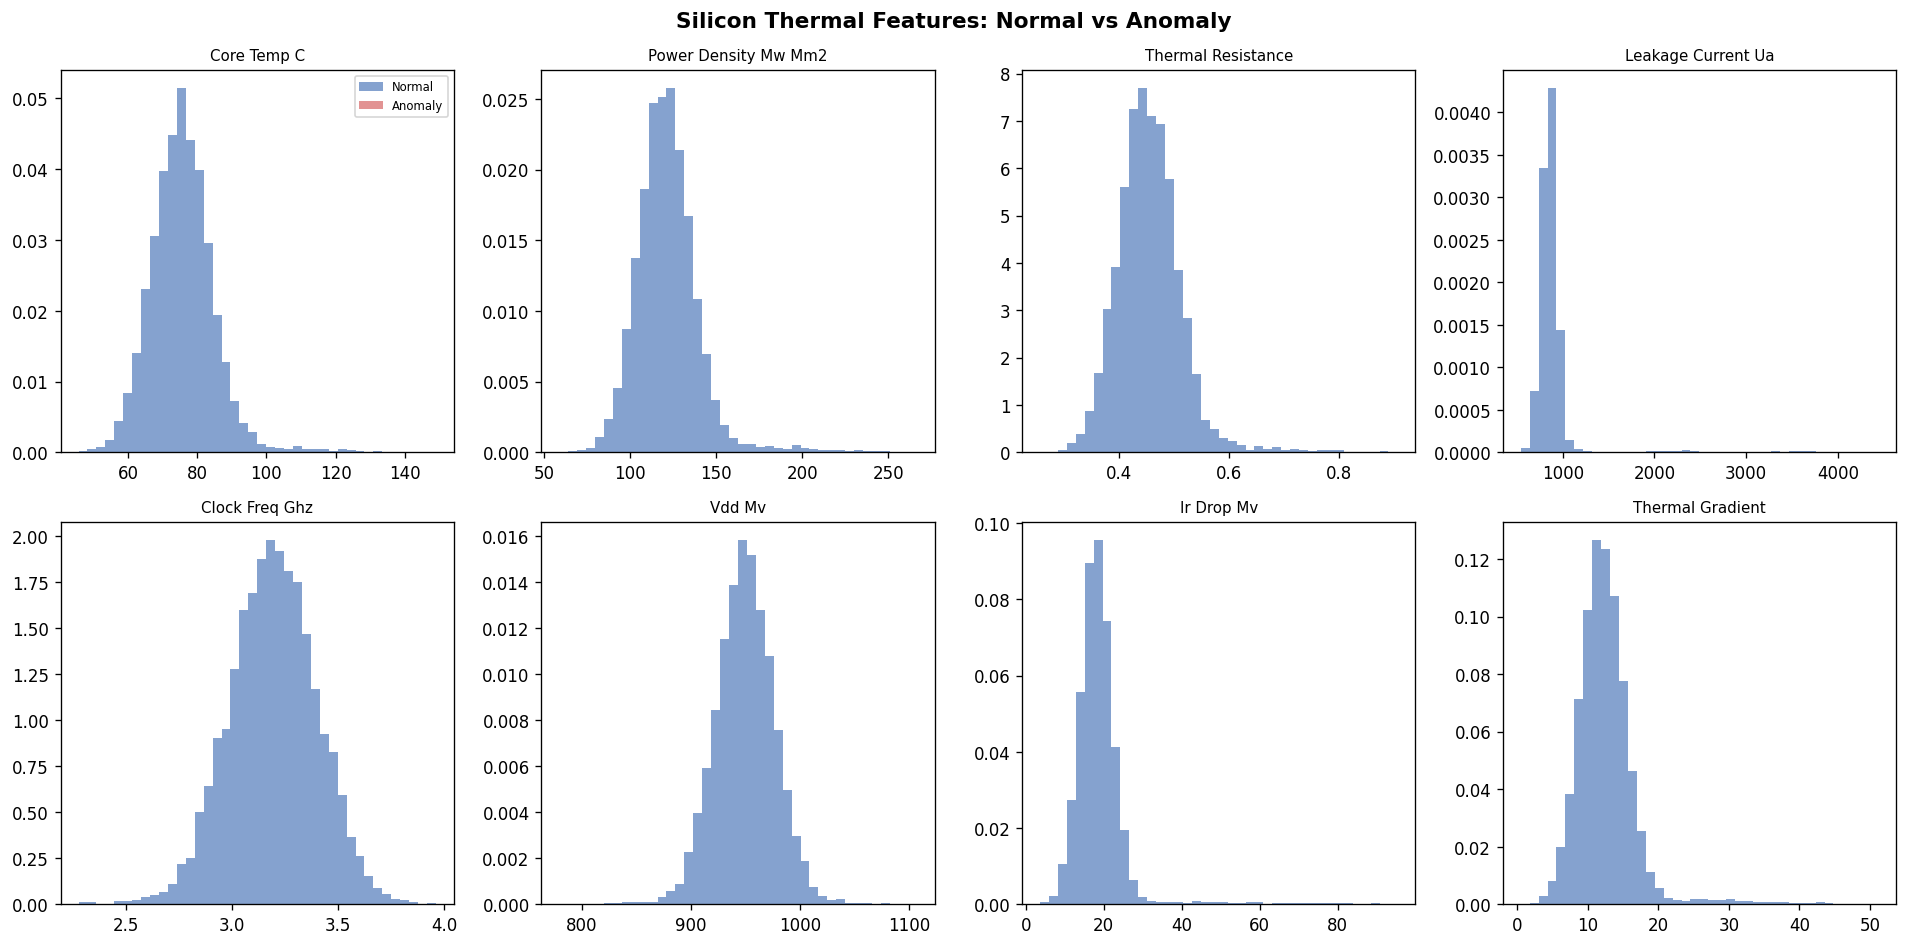

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(feature_names):
    ax = axes[i // 4, i % 4]
    for label, color, name in [(0, COLORS['primary'], 'Normal'), (1, COLORS['highlight'], 'Anomaly')]:
        ax.hist(X[y_true == label][col], bins=40, alpha=0.5, color=color, density=True, label=name)
    ax.set_title(col.replace('_', ' ').title(), fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)
plt.suptitle('Silicon Thermal Features: Normal vs Anomaly', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/eda_silicon_thermal.png', dpi=150, bbox_inches='tight')
plt.show()

---## 4. Isolation Forest

In [4]:
iso = IsolationForest(contamination=0.032, random_state=42, n_estimators=200)
iso_pred = iso.fit_predict(X_scaled)
iso_labels = (iso_pred == -1).astype(int)
iso_scores = -iso.decision_function(X_scaled)

print(f'Isolation Forest ROC-AUC: {roc_auc_score(y_true, iso_scores):.3f}')
print(f'Detected: {iso_labels.sum()} / {y_true.sum()} actual anomalies')
print(classification_report(y_true, iso_labels, target_names=['Normal', 'Anomaly']))

Isolation Forest ROC-AUC: nan
Detected: 298 / 0 actual anomalies
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98      9300
     Anomaly       0.00      0.00      0.00         0

    accuracy                           0.97      9300
   macro avg       0.50      0.48      0.49      9300
weighted avg       1.00      0.97      0.98      9300



/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-p

---## 5. PCA vs t-SNE vs UMAP

/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


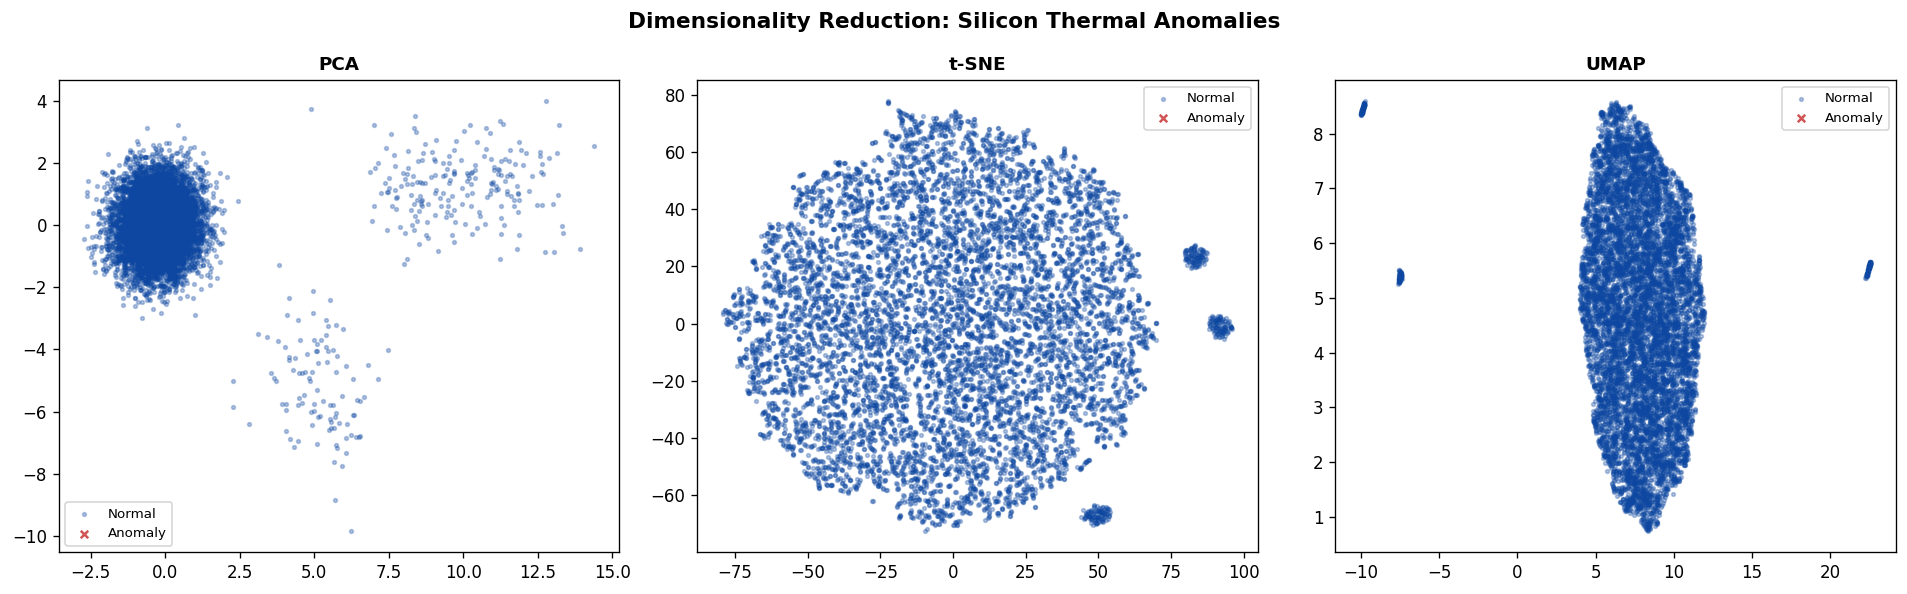

In [5]:
X_pca = PCA(n_components=2).fit_transform(X_scaled)
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(X_scaled)
X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, X_proj, title in zip(axes, [X_pca, X_tsne, X_umap], ['PCA', 't-SNE', 'UMAP']):
    normal = y_true == 0
    ax.scatter(X_proj[normal, 0], X_proj[normal, 1], alpha=0.3, s=5, c=COLORS['primary'], label='Normal')
    ax.scatter(X_proj[~normal, 0], X_proj[~normal, 1], alpha=0.8, s=20, c=COLORS['highlight'], marker='x', label='Anomaly')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Dimensionality Reduction: Silicon Thermal Anomalies', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/dim_reduction_silicon.png', dpi=150, bbox_inches='tight')
plt.show()

---## 6. Anomaly Score Analysis

/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


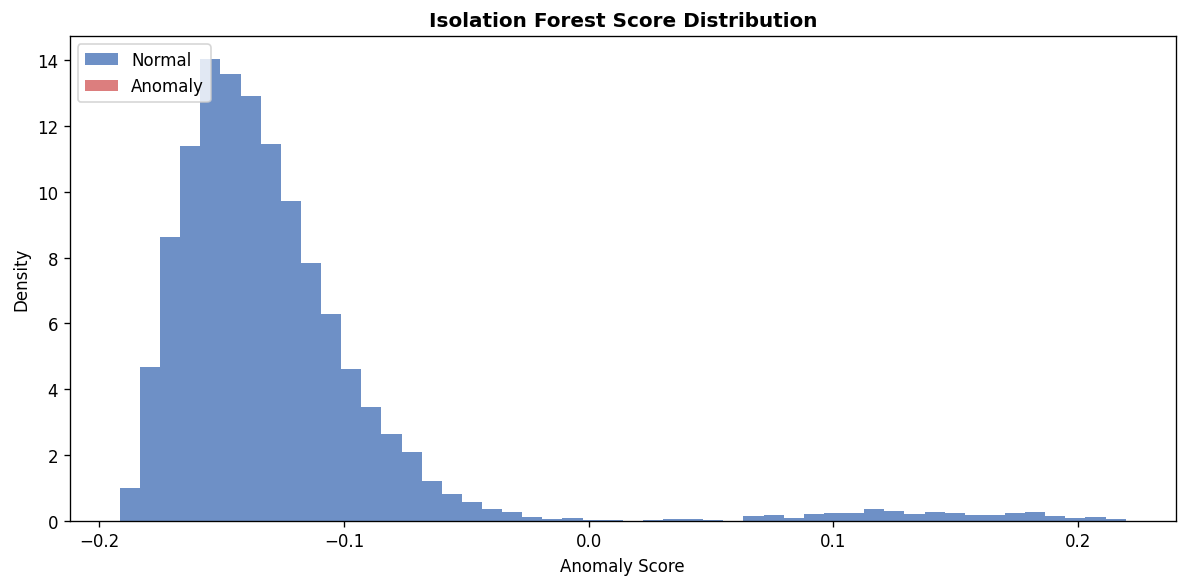

Final ROC-AUC: nan
Notebook complete.


/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(iso_scores[y_true == 0], bins=50, alpha=0.6, color=COLORS['primary'], label='Normal', density=True)
ax.hist(iso_scores[y_true == 1], bins=50, alpha=0.6, color=COLORS['highlight'], label='Anomaly', density=True)
ax.set_xlabel('Anomaly Score'); ax.set_ylabel('Density')
ax.set_title('Isolation Forest Score Distribution', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../assets/anomaly_scores_silicon.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Final ROC-AUC: {roc_auc_score(y_true, iso_scores):.3f}')
print('Notebook complete.')